# Compute the nucleosome shift of the +1, and if possible, +2, and +3

May 8, 2024

Goal: Create a procedure to compute the shift of the +1 nucleosome.

1. First look at some examples of nucleosome positioning for various phases of the cell cycle. By eye is there a shift that is computable.
2. Design a procedure to compute the +1 nucleosome based on neighbor bins of nucleosome fragment length.
3. Compute the shift from the baseline +1 position for all genes.


In [10]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
from src.promoter_ptr_analysis import PromoterPTRAnalysis

chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'
promoter_analysis = PromoterPTRAnalysis(chromatin_dir)

In [18]:
promoter_analysis.load_f_files()

Shape of the loaded F: (227, 200)
1/5574 - 00:00:00.200
1001/5574 - 00:00:07.096
2001/5574 - 00:00:13.141
3001/5574 - 00:00:18.967
4001/5574 - 00:00:24.719
5001/5574 - 00:00:30.548


In [19]:
promoter_analysis.correct_f_images_by_strand()

In [420]:
from src.nuc_p1_shift_analysis import ComputePlusOneShiftAnalysis

plus_one_analysis = ComputePlusOneShiftAnalysis(promoter_analysis)

In [475]:
plus_one_analysis.compute_p1_shift()

In [476]:
plus_one_analysis.normalize_plus_ones()

In [477]:
plus_one_analysis.join_with_replication_timing()

In [478]:
plus_one_analysis.save_plus_ones('output/deconvolved_plus_one_tracking')

In [479]:
# Plot a few gene examples where the +1 nucleosome is tracked

In [510]:
# A list of the genes with the greatest shift upstream or downstream
# Filtered for low nucleosome reads
shift_df = plus_one_analysis.repl_w_nuc_max
shift_df = shift_df[shift_df.bin_max > 9]
shift_df.sort_values('max_difference_shift').head()

,gene,TSS,chr,strand,f_gene_index,replication_timing,replication_H_index,expression_at_replication,replication_direction,bin_max,max_difference_shift,gene_idx
orf_name,,,,,,,,,,,,
YGR026W,YGR026W,532846,7,+,1866,46.746785,183,11.816986,right,9.888543,0.018163,1980
YOR334W,MRS2,944597,15,+,4786,52.809385,195,9.601477,left,9.412806,0.019105,5082
YJR100C,AIM25,617412,10,-,2791,36.137385,162,10.182539,right,20.411739,0.028266,2968
YML092C,PRE8,86761,13,-,3624,40.179085,170,11.779484,left,9.678263,0.036945,3842
YGL127C,SOH1,270811,7,-,1735,48.767685,187,9.601654,right,9.813334,0.038328,1842


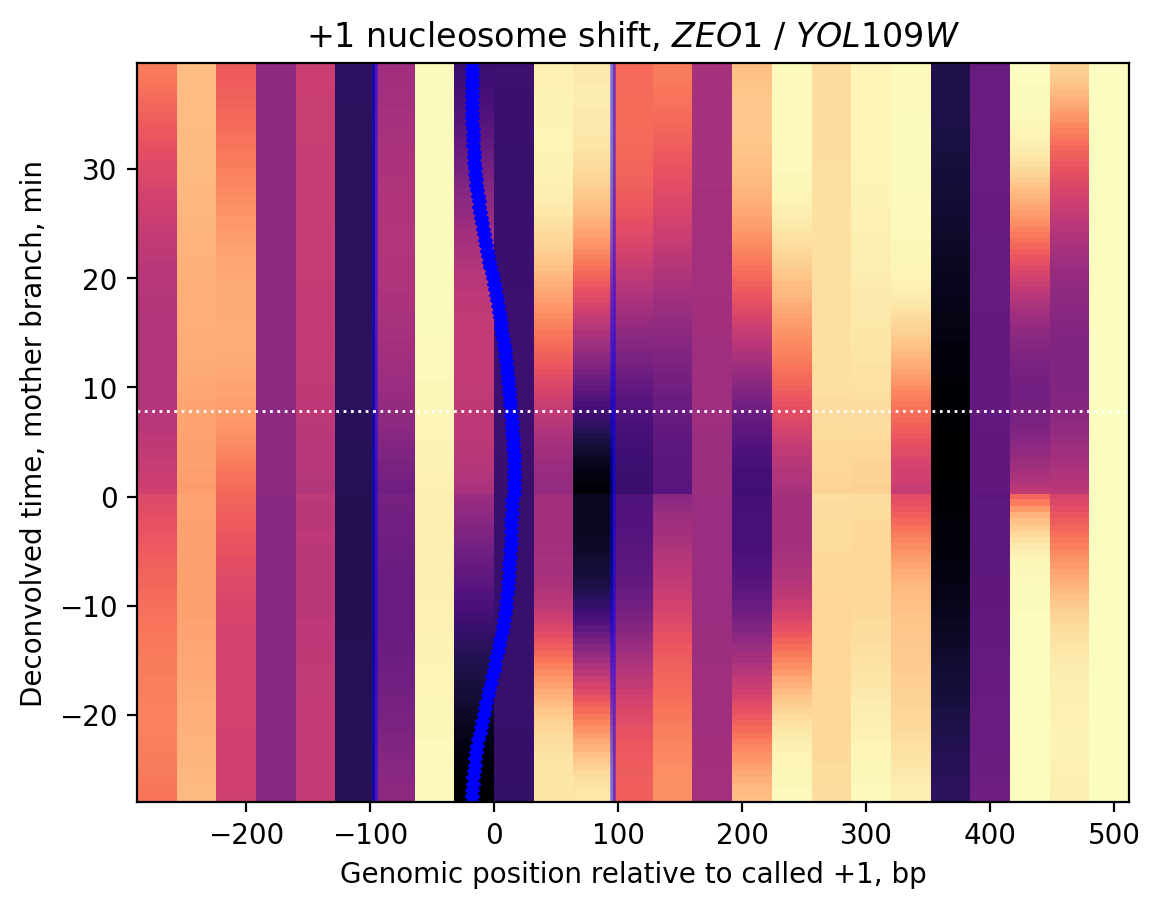

In [518]:
plus_one_analysis.show_plus_one_shift_for_gene('ZEO1')

In [505]:
# Create traceplots for entropy, small fragments enrichment and gene expression.

# Create annotations on deconvolved gene for nucleosome region, +1, 
# and promoter small fragments

# Consolidate and locate all the measures we have, ptr, chrom metrics, replication, etc...
# Document where they are where they are computed, etc...
